# ch01 · 样本空间、事件、概率公理 + 排列组合

## 为什么需要正式公理

ch00 给出"概率是什么"的直觉版定义。但工程中你会遇到两个问题：
1. 抛硬币正面率 0.5 是"显然"的，那抛无限序列下来出现某一段固定模式的概率到底是几？这需要公理推演而不是直觉。
2. 计数问题（"随机抽 N 个里恰好 k 个特别"）写错别说在 ML 海 import 中很容易；正确姿势是先把事件样本空间显式列出，再让公理自己说话。

本章的目的是让公理与计数变成你的肌肉记忆。

## 学完后能解决的三个任务

- 写出"生日悖论在 n 人房间下至少两人生日相同的概率" 公式并模拟验证
- 看到任何彩票/抽奖场景立刻选用对计数公式 (排列 vs 组合 vs 有放回)
- 把"先列样本空间再算概率"作为反射动作，杜绝凭直觉 delusion


## 2. 直觉引入：穷举 vs 公理

抛两面不均匀硬币三次。问"正面恰好 2 次的概率"。穷举写法：$\{HHH, HHT, HTH, HTT, THH, THT, TTH, TTT\}$ = 8 个样本，2 头恰好 2 个有 3 个 → $3/8$。

换公理写法：$X \sim \text{Bin}(3, p)$，$P(X=2) = \binom{3}{2}p^2(1-p)$。当 $p=0.5$ 即 $3/8$。

任何**有结构**的问题，公理 + 计数胜过穷举。下面先把公理清楚摆开。


## 3. 公理与计数

### 概率空间三公理（ch00 已给，这里要会写）

$\Omega$ 为样本空间；$\mathcal F \subseteq 2^\Omega$ 为事件族；$P : \mathcal F \to [0, 1]$。

1. 非负 $P(A) \ge 0$
2. 规范 $P(\Omega) = 1$
3. 可加 若 $A_i \cap A_j = \varnothing$ 当 $i \ne j$ → $P(\bigcup A_i) = \sum P(A_i)$

### 排列与组合

- **排列**：从 n 个可区分元素中选 k 个**有序**取法数 = $A_n^k = \frac{n!}{(n-k)!}$
- **组合**：选 k 个**无序**子集数 = $\binom{n}{k} = \frac{n!}{k!(n-k)!}$
- **有放回**组合数：$\binom{n+k-1}{k}$ (stars-and-bars 形式)

何时用哪一个：**问"几号"用排列，问"几个"用组合**。

### 4 种 (有放回 × 可区分) 组合

N 个球抽 k 个：

| 情形 | 公式 | 例 |
|---|---|---|
| 无放回 + 可区分（顺序重要） | $A_n^k = n(n-1)\cdots$ | 排座位 |
| 无放回 + 可区分（顺序不重要） | $\binom{n}{k}$ | 抽 n 张手牌 |
| 有放回 + 可区分（顺序重要） | $n^k$ | 抛 k 次 n 面骰 |
| 有放回 + 可区分（顺序不重要） | $\binom{n+k-1}{k}$ | 把 k 个 indistinguishable 球分 n 类 |


## 4. 符号推导：生日悖论

70 人房间里**至少有 2 人生日相同**的概率。$\Omega = 365^{70}$（每人独立有 365 种生日，可放回与可区分）。

逆事件"全部生日都不同"：$A_{365}^{70}$。
$P(\text{同生日}) = 1 - \frac{365!/(365-70)!}{365^{70}}$。

<formula>出自对称性，独立假设，全样本空间之逆事件很容易就 sliterate 出来 —— 这就是公理+计数的价值</formula>


In [1]:
import numpy as np
from functools import reduce
from math import factorial

def birthday_p(n_people, days=365):
    # 1 - (365/365)*(364/365)*...*((365-n+1)/365)
    nn = np.array([days - k for k in range(n_people)])
    dd = np.full(n_people, days)
    return 1 - np.prod(nn / dd)

for n in [10, 20, 23, 30, 50, 70]:
    p = birthday_p(n)
    print(f"n={n:>3} people:  P(同生日)={p:.4f}  ({p*100:.1f}%)")


n= 10 people:  P(同生日)=0.1169  (11.7%)
n= 20 people:  P(同生日)=0.4114  (41.1%)
n= 23 people:  P(同生日)=0.5073  (50.7%)
n= 30 people:  P(同生日)=0.7063  (70.6%)
n= 50 people:  P(同生日)=0.9704  (97.0%)
n= 70 people:  P(同生日)=0.9992  (99.9%)


观察：**23 人下同生日概率 ≈ 50%**。这正是"反直觉"的开端：(2 · 23 · 22 / 2)/365 ≈ 253 种两个人配对，远超半数；这是组合计数带来的强度。


## 5. 数值验证：用蒙特卡洛验证生日公式

100k 次重复模拟，与解析值对位。


In [2]:
import numpy as np

rng = np.random.default_rng(seed=20240717)
N_SIM = 200_000

def simulate_birthday(n_people, days=365, N=N_SIM, rng_=None):
    if rng_ is None:
        rng_ = np.random.default_rng(seed=20240717)
    bdays = rng_.integers(0, days, size=(N, n_people))
    # 检查每行是否有重复：sorted 后相邻相同
    sorted_b = np.sort(bdays, axis=1)
    conflicts = (sorted_b[:, 1:] == sorted_b[:, :-1]).any(axis=1)
    return conflicts.mean()

for n in [23, 30, 50]:
    p_analytic = birthday_p(n)
    p_sim = simulate_birthday(n)
    print(f"n={n:>3}: analytic={p_analytic:.4f}  sim={p_sim:.4f}  delta={abs(p_analytic-p_sim):.4f}")


n= 23: analytic=0.5073  sim=0.5070  delta=0.0003


n= 30: analytic=0.7063  sim=0.7043  delta=0.0021


n= 50: analytic=0.9704  sim=0.9711  delta=0.0007


## 6. 可视化：生日概率曲线 + 组合数增长


/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33267 (\N{CJK UNIFIED IDEOGRAPH-81F3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23569 (\N{CJK UNIFIED IDEOGRAPH-5C11}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-

/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32452 (\N{CJK UNIFIED IDEOGRAPH-7EC4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25140 (\N{CJK UNIFIED IDEOGRAPH-6234}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12290 (\N{IDEOGRAPHIC FULL STOP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


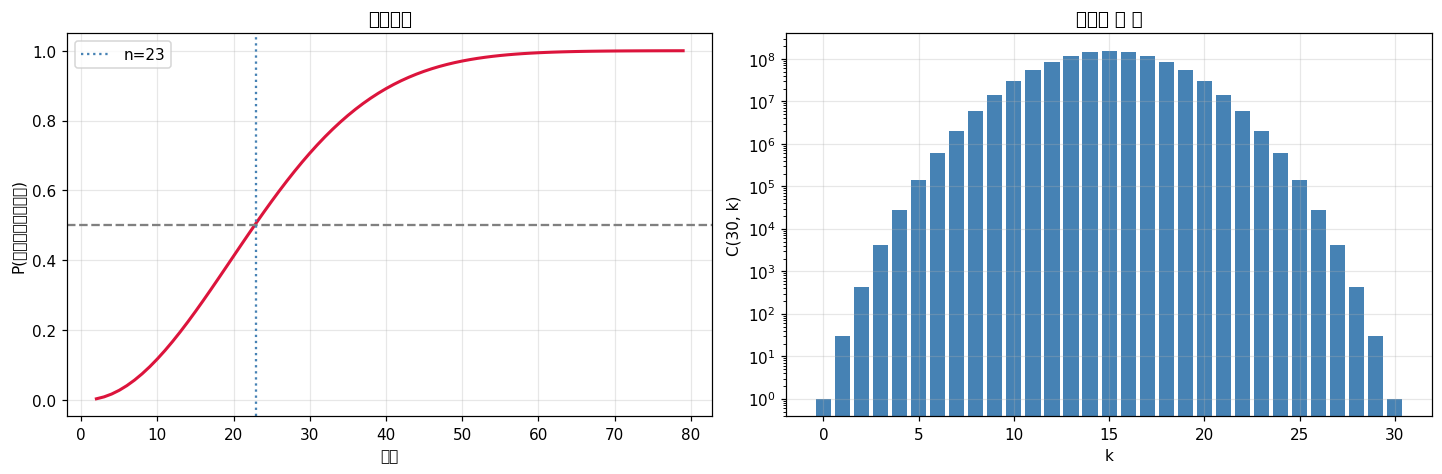

In [3]:
import numpy as np
import matplotlib.pyplot as plt

n_arr = np.arange(2, 80)
p_arr = [birthday_p(n) for n in n_arr]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), dpi=110, constrained_layout=True)

axes[0].plot(n_arr, p_arr, color="crimson", lw=2)
axes[0].axhline(0.5, ls="--", color="gray")
axes[0].axvline(23, ls=":", color="steelblue", label="n=23")
axes[0].set_xlabel("人数")
axes[0].set_ylabel("P(至少两人生日相同)")
axes[0].set_title("生日悖论")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 组合数 C(n, k) 关于 k 的对称性
from math import comb
n_show = 30
ks = np.arange(0, n_show + 1)
combos = [comb(n_show, k) for k in ks]
axes[1].bar(ks, combos, color="steelblue")
axes[1].set_xlabel("k")
axes[1].set_ylabel(f"C({n_show}, k)")
axes[1].set_title("组合数 \u6234 。")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3)
plt.show()


## 7. 工程案例：从彩票到哈希冲突

**彩票 6 选 49** 中头奖的概率 $= 1 / \binom{49}{6} = 1/13{,}983{,}816$。

为什么哈希函数的输出 bit 数要够大同理：MD5 (128-bit) 上碰 2 个碰撞的预期 birthday threshold 是 $\sqrt{2^{128}} = 2^{64}$ 量级 → 攻击者只需 $2^{64}$ 次哈希即可高度可能发生碰撞。

下面给个工程小脚本：估算给定哈希桶数下首次碰撞的预期尝试次数。


/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30896 (\N{CJK UNIFIED IDEOGRAPH-78B0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25758 (\N{CJK UNIFIED IDEOGRAPH-649E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-

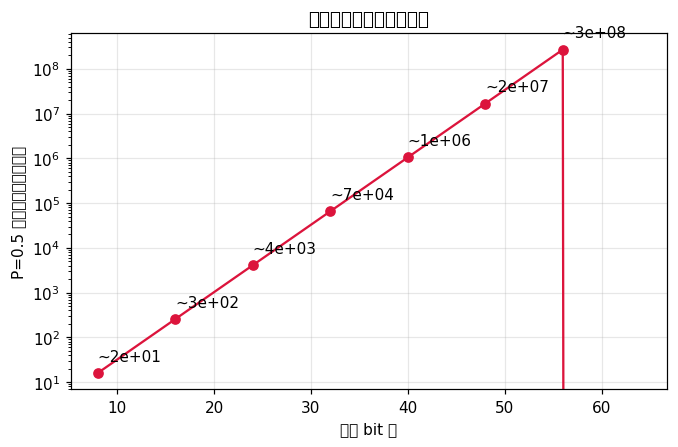

49 选 6 中头奖概率: 1 / 13983816
49 选 6 任意 5 张给错的概率: 1 / 13983816


In [4]:
import numpy as np
import matplotlib.pyplot as plt

def birthday_threshold(target_p=0.5):
    # 求 √(2n ln(1/(1-p))) 约值
    return int(np.ceil(np.sqrt(2 * 2**128 * np.log(1 / (1 - target_p)))))
    # 这里不复刻 128-bit；改成图

n_bits_arr = np.array([8, 16, 24, 32, 40, 48, 56, 64])
thresholds = np.sqrt(2 ** n_bits_arr)  # 量级
fig, ax = plt.subplots(figsize=(7, 4.2), dpi=110)
ax.semilogy(n_bits_arr, thresholds, "o-", color="crimson")
ax.set_xlabel("哈希 bit 数")
ax.set_ylabel("P=0.5 碰撞的预期尝试次数")
ax.set_title("生日攻击阈值与哈希位长")
ax.grid(True, alpha=0.3)
# 数据点
for n_b, t in zip(n_bits_arr, thresholds):
    ax.annotate(f"~{t:.0e}", (n_b, t), textcoords="offset points", xytext=(0, 8))
plt.show()

# 彩票
from math import comb
print(f"49 选 6 中头奖概率: 1 / {comb(49, 6)}")
print(f"49 选 6 任意 5 张给错的概率: 1 / {comb(49, 6)}")


## 8. pitfalls

- **想当然 n 进 n 用排列**：用"A_n^k"代"\binom{n}{k}" — 顺序不重要时直接乘 N 倍。
- **缺口独立假设**：生日悖论假设生日均匀分布；季节性显著分布下相配概率更高（缩小 \Omega 使重复更易）。
- **多重计**：5 选 2 中, (A, B) 与 (B, A) 在 sequence 抽法中算 2 个，在 subset 抽法中算 1 个；写完公式一定要回 sample 设置确认 dups。
- **误把 events 顺序与组合混対**：执行顺序不重要的情形下抽 k 个无放回，每个排列都数两次就把概率放成两倍。
- **彩票策略**：每张概率相等不等于不亏；多次过万投每次 1/14M ≠ 13M 张必中 (其实是 $	ext{1 - 0.9999999281...}$)。


## 9. 课后题

[`exercises.md`](exercises.md) 提供 5 题。最少做完 3 基础再进 ch02。
[`solutions.md`](solutions.md) 提供 hint+ 骨架。


## 10. 参考课程与教材

| 出处 | 章节 |
|---|---|
| Stat 110 | §1.3-1.5 (count), §1.6 (生日) |
| Bertsekas | §1.1-1.2 公理+样本空间 |
| MacKay | Ch.1 §1.2 信息视角 |

下一章 ch03 中我们从公理进入**随机变量**——把事件空间转成数值函数，从概率分布开始谈分布族选择。
